# 산불 진화 접근성 종합 EDA

산불 발생 지점별로 임도, 소방서, 소방용수시설, 산불소화시설, 지형 조건을 함께 붙여 **진화 접근성 취약도**를 분석합니다.

핵심 질문:
- 임도와 소방서가 모두 먼 산불 지점은 어디인가?
- 임도 접근은 가능하지만 소방용수가 부족한 지역은 어디인가?
- 경사가 높고 고도가 높으면서 진화 인프라도 먼 산불 지점은 어디인가?
- 종합 점수 기준으로 우선 관리해야 할 접근 취약 지역은 어디인가?

주의: 별도 GIS 패키지 없이 실행되도록 위경도를 미터 좌표로 근사 변환해 거리 계산합니다. 임도는 `LINESTRING` 좌표점을 샘플링해 최근접 거리를 근사 계산합니다.

In [1]:
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
DATA_DIR = ROOT / "data" / "processed"
OUT_DIR = ROOT / "outputs" / "integrated_accessibility_eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIRE_PATH = DATA_DIR / "산불발생위치도_지형특성계산.csv"
ROAD_PATH = DATA_DIR / "전국_임도망도.csv"
STATION_PATH = DATA_DIR / "전국_소방서_좌표.csv"
WATER_PATH = DATA_DIR / "전국_소방용수시설.csv"
FOREST_EXT_PATH = DATA_DIR / "전국_산불소화시설.csv"

## 1. 데이터 로드 및 좌표 정리

In [2]:
fires = pd.read_csv(FIRE_PATH)
roads = pd.read_csv(ROAD_PATH)
stations = pd.read_csv(STATION_PATH)
water = pd.read_csv(WATER_PATH)
forest_ext = pd.read_csv(FOREST_EXT_PATH)

def filter_korea_bbox(df, lat_col="위도", lon_col="경도"):
    return df[df[lat_col].between(32, 39.5) & df[lon_col].between(124, 132)].copy()

fires = filter_korea_bbox(fires)
stations = filter_korea_bbox(stations)
water = filter_korea_bbox(water)
forest_ext = filter_korea_bbox(forest_ext)

print("산불:", fires.shape)
print("임도:", roads.shape)
print("소방서/안전센터:", stations.shape)
print("소방용수시설:", water.shape)
print("산불소화시설:", forest_ext.shape)

display(fires.head(2))
display(stations.head(2))
display(water.head(2))
display(forest_ext.head(2))

산불: (25036, 9)
임도: (3322, 22)
소방서/안전센터: (1216, 7)
소방용수시설: (192029, 8)
산불소화시설: (187, 11)


,fire_id,위도,경도,고도(m),경사도(도),사면방향_sin,사면방향_cos,TPI(지형위치지수),TWI(지형다습지수)
0,F_000000,37.635100,126.997582,233.92538,19.854153,-0.998277,-0.058677,-2.599762,5.503641
1,F_000001,37.450793,127.069168,121.87208,8.362768,0.059167,-0.998248,1.706253,2.001579


,소방서 및 안전센터명,위도,경도,시도,시군구,상세주소,상위 본부명
0,수성소방서-수성-119 안전센터,35.856757,128.620850,대구광역시,수성구,들안로60길 30,대구소방안전본부
1,수성소방서-황금-119 안전센터,35.835493,128.626425,대구광역시,수성구,동대구로12길 41,대구소방안전본부


,시설유형,시설유형코드,시도명,시군구명,소재지지번주소,위도,경도,안전센터명
0,NaN,6,광주광역시,광산구,광주광역시 광산구 양산동 419,35.200021,126.686238,빛그린119안전센터
1,NaN,6,광주광역시,광산구,광주광역시 광산구 산수동 290,35.183677,126.740180,빛그린119안전센터


,경도,위도,원격제어,관리기관1,관리기관2,보호대상구분,보호대상물,설치년도,시도,시군구,상세주소
0,127.013400,37.475780,불가능,서울특별시,서초구,문화재,대성사,2012,서울특별시,서초구,서초동 산140-1
1,127.099387,37.553812,가능,서울특별시,광진구,주요기반시설,주거밀집지,2013,서울특별시,광진구,구의동 3-3


## 2. 거리 계산 함수

점 데이터는 격자 인덱스를 사용해 최근접 시설을 찾습니다. 임도는 `LINESTRING` 좌표를 샘플링한 점 집합으로 변환한 뒤 같은 방식으로 계산합니다.

In [3]:
def lonlat_to_meter(lon, lat, lat0=36.5):
    radius = 6_371_000
    x = np.deg2rad(lon) * radius * np.cos(np.deg2rad(lat0))
    y = np.deg2rad(lat) * radius
    return x, y

def nearest_distances(source_lon, source_lat, target_lon, target_lat, cell_size=10_000, max_radius_cells=30):
    target_x, target_y = lonlat_to_meter(np.asarray(target_lon), np.asarray(target_lat))
    source_x, source_y = lonlat_to_meter(np.asarray(source_lon), np.asarray(source_lat))

    target_ix = np.floor(target_x / cell_size).astype(int)
    target_iy = np.floor(target_y / cell_size).astype(int)
    grid = {}
    for idx, key in enumerate(zip(target_ix, target_iy)):
        grid.setdefault(key, []).append(idx)

    nearest = np.empty(len(source_x), dtype=float)
    for i, (x, y) in enumerate(zip(source_x, source_y)):
        cx = int(math.floor(x / cell_size))
        cy = int(math.floor(y / cell_size))
        candidates = []

        for radius in range(max_radius_cells + 1):
            for gx in range(cx - radius, cx + radius + 1):
                for gy in range(cy - radius, cy + radius + 1):
                    if radius == 0 or gx in (cx - radius, cx + radius) or gy in (cy - radius, cy + radius):
                        candidates.extend(grid.get((gx, gy), []))
            if candidates:
                dx = target_x[candidates] - x
                dy = target_y[candidates] - y
                nearest[i] = np.sqrt(dx * dx + dy * dy).min()
                break
        else:
            nearest[i] = np.nan

    return nearest / 1000

coord_pattern = re.compile(r"([0-9]+\.[0-9]+) ([0-9]+\.[0-9]+)")

def sample_road_points(road_df, step=10):
    lons = []
    lats = []
    for wkt in road_df["공간좌표"].dropna():
        points = coord_pattern.findall(str(wkt))
        if len(points) > step:
            points = points[::step]
        for lon, lat in points:
            lons.append(float(lon))
            lats.append(float(lat))
    return pd.DataFrame({"경도": lons, "위도": lats})

## 3. 산불 지점별 최근접 인프라 거리 계산

In [4]:
road_points = sample_road_points(roads, step=10)
print("샘플링된 임도 좌표점:", len(road_points))

access = fires.copy()
access["임도거리_km"] = nearest_distances(access["경도"], access["위도"], road_points["경도"], road_points["위도"])
access["소방서거리_km"] = nearest_distances(access["경도"], access["위도"], stations["경도"], stations["위도"])
access["소방용수거리_km"] = nearest_distances(access["경도"], access["위도"], water["경도"], water["위도"])
access["산불소화시설거리_km"] = nearest_distances(access["경도"], access["위도"], forest_ext["경도"], forest_ext["위도"])

distance_cols = ["임도거리_km", "소방서거리_km", "소방용수거리_km", "산불소화시설거리_km"]
access[["fire_id", "위도", "경도"] + distance_cols].head()

샘플링된 임도 좌표점: 154192


,fire_id,위도,경도,임도거리_km,소방서거리_km,소방용수거리_km,산불소화시설거리_km
0,F_000000,37.635100,126.997582,15.304539,1.819163,0.803334,4.428653
1,F_000001,37.450793,127.069168,23.092720,3.172605,0.128086,5.706884
2,F_000002,37.681290,127.016965,11.442156,2.711120,1.093936,6.449693
3,F_000003,37.502707,127.147636,17.639727,2.139720,0.091987,7.133844
4,F_000004,37.617382,127.037494,16.047260,0.871783,0.096931,2.418294


In [5]:
distance_summary = access[distance_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).T
distance_summary.round(2)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
임도거리_km,25036.0,11.85,14.01,0.00,2.10,4.00,7.65,14.59,25.17,34.85,201.51
소방서거리_km,25036.0,7.43,10.66,0.02,0.93,2.07,5.08,8.58,13.02,19.59,109.22
소방용수거리_km,25036.0,2.80,8.97,0.00,0.11,0.25,0.66,1.65,4.12,8.13,94.99
산불소화시설거리_km,25036.0,14.88,12.37,0.03,4.32,7.32,12.41,19.18,26.00,31.58,184.84


## 4. 거리 분포와 인프라 조합 분석

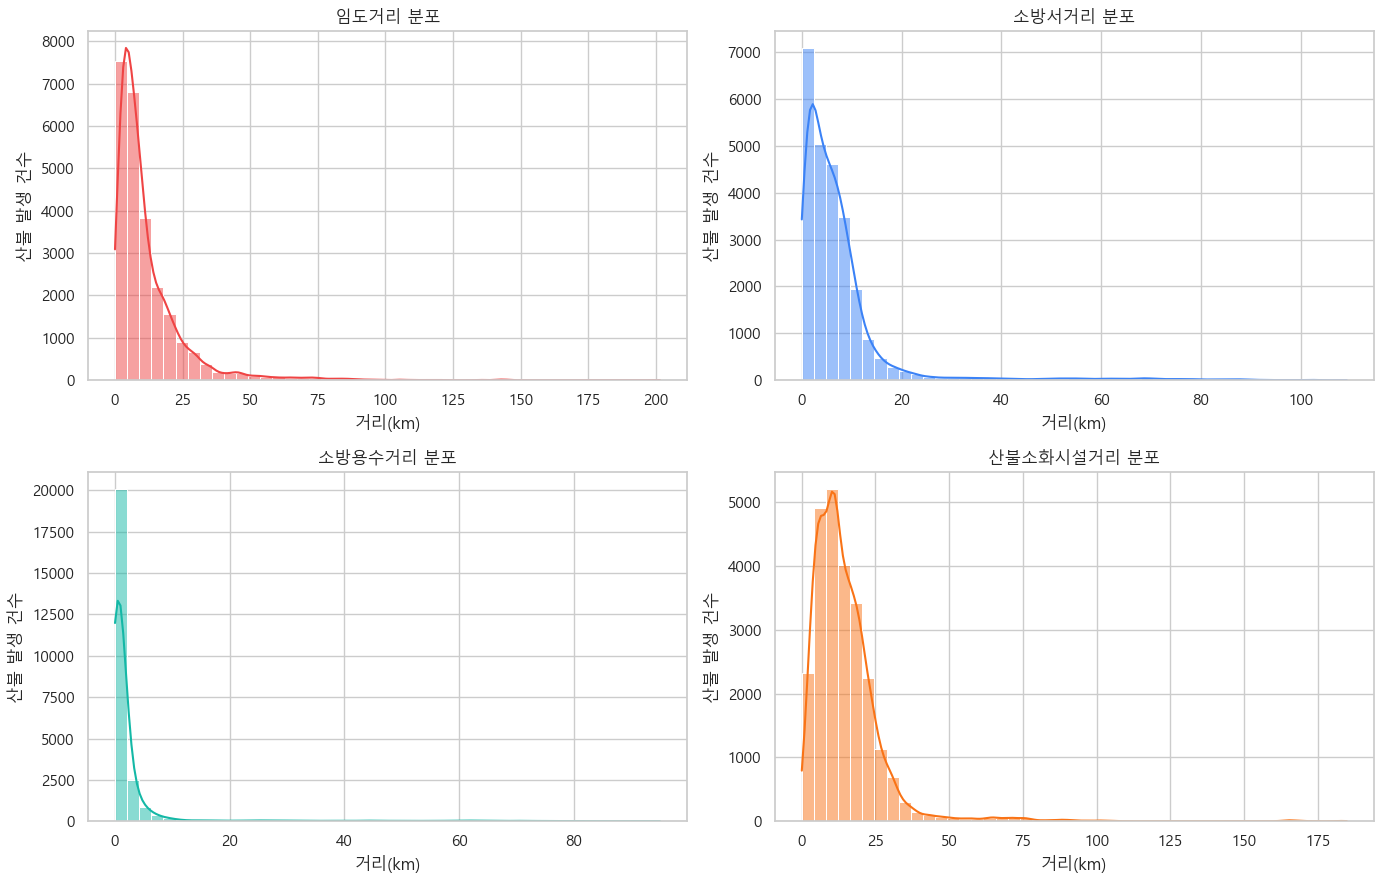

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = ["#ef4444", "#3b82f6", "#14b8a6", "#f97316"]

for ax, col, color in zip(axes.ravel(), distance_cols, colors):
    sns.histplot(access[col].dropna(), bins=45, kde=True, ax=ax, color=color)
    ax.set_title(col.replace("_km", " 분포"))
    ax.set_xlabel("거리(km)")
    ax.set_ylabel("산불 발생 건수")

plt.tight_layout()
plt.savefig(OUT_DIR / "infrastructure_distance_histograms.png", dpi=160)
plt.show()

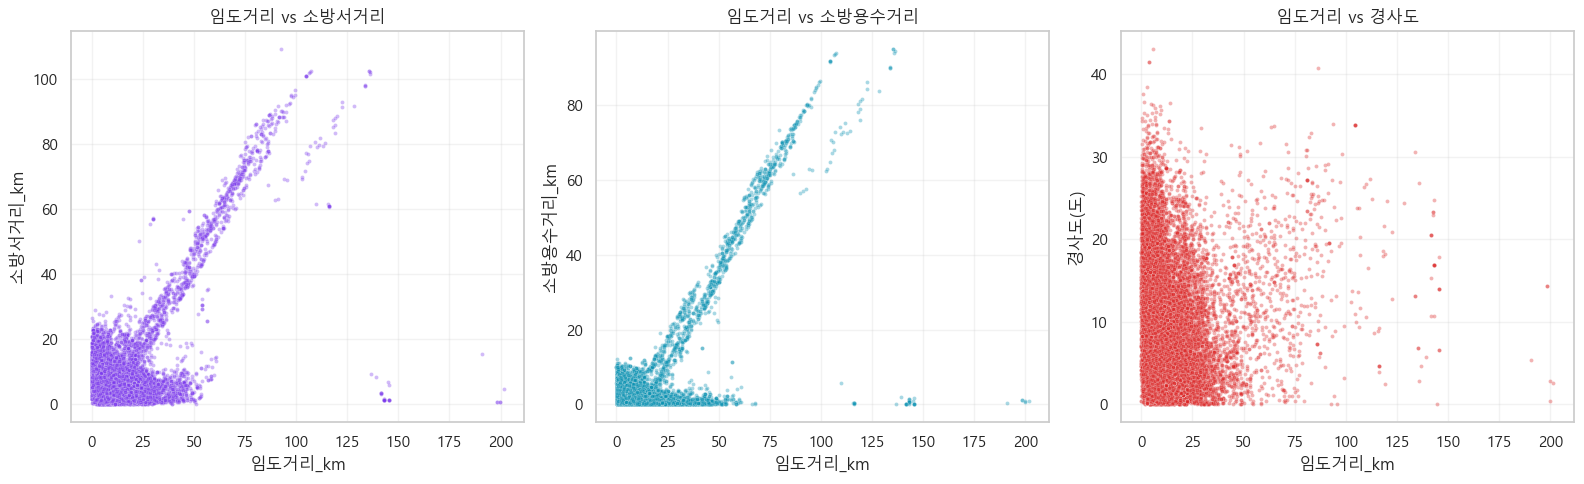

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=access, x="임도거리_km", y="소방서거리_km", s=8, alpha=0.35, ax=axes[0], color="#7c3aed")
axes[0].set_title("임도거리 vs 소방서거리")

sns.scatterplot(data=access, x="임도거리_km", y="소방용수거리_km", s=8, alpha=0.35, ax=axes[1], color="#0891b2")
axes[1].set_title("임도거리 vs 소방용수거리")

sns.scatterplot(data=access, x="임도거리_km", y="경사도(도)", s=8, alpha=0.35, ax=axes[2], color="#dc2626")
axes[2].set_title("임도거리 vs 경사도")

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_DIR / "accessibility_pair_scatter.png", dpi=160)
plt.show()

## 5. 진화 접근성 취약 점수 만들기

거리와 지형 조건을 0~100 점수로 정규화합니다. 점수가 높을수록 접근 취약성이 크다는 뜻입니다.

가중치 예시:
- 임도거리 30%
- 소방서거리 20%
- 소방용수거리 20%
- 산불소화시설거리 15%
- 경사도 10%
- 고도 5%

In [8]:
def cap_score(series, cap):
    return (series.clip(lower=0, upper=cap) / cap * 100).fillna(100)

access["임도취약점수"] = cap_score(access["임도거리_km"], 20)
access["소방서취약점수"] = cap_score(access["소방서거리_km"], 30)
access["소방용수취약점수"] = cap_score(access["소방용수거리_km"], 10)
access["산불소화시설취약점수"] = cap_score(access["산불소화시설거리_km"], 30)
access["경사취약점수"] = cap_score(access["경사도(도)"], 30)
access["고도취약점수"] = cap_score(access["고도(m)"], 500)

access["진화접근취약점수"] = (
    access["임도취약점수"] * 0.30
    + access["소방서취약점수"] * 0.20
    + access["소방용수취약점수"] * 0.20
    + access["산불소화시설취약점수"] * 0.15
    + access["경사취약점수"] * 0.10
    + access["고도취약점수"] * 0.05
)

access["접근취약등급"] = pd.cut(
    access["진화접근취약점수"],
    bins=[0, 35, 55, 70, 100],
    labels=["낮음", "보통", "높음", "매우 높음"],
    include_lowest=True,
)

score_cols = [
    "임도취약점수", "소방서취약점수", "소방용수취약점수", "산불소화시설취약점수",
    "경사취약점수", "고도취약점수", "진화접근취약점수", "접근취약등급"
]
access[["fire_id", "위도", "경도"] + distance_cols + score_cols].head()

,fire_id,위도,경도,임도거리_km,소방서거리_km,소방용수거리_km,산불소화시설거리_km,임도취약점수,소방서취약점수,소방용수취약점수,산불소화시설취약점수,경사취약점수,고도취약점수,진화접근취약점수,접근취약등급
0,F_000000,37.635100,126.997582,15.304539,1.819163,0.803334,4.428653,76.522693,6.063877,8.033340,14.762176,66.180511,46.785076,36.947882,보통
1,F_000001,37.450793,127.069168,23.092720,3.172605,0.128086,5.706884,100.000000,10.575349,1.280861,19.022948,27.875893,24.374416,39.230994,보통
2,F_000002,37.681290,127.016965,11.442156,2.711120,1.093936,6.449693,57.210782,9.037067,10.939358,21.498977,57.472894,54.901452,32.875728,낮음
3,F_000003,37.502707,127.147636,17.639727,2.139720,0.091987,7.133844,88.198636,7.132401,0.919870,23.779478,18.367710,7.906527,33.869064,낮음
4,F_000004,37.617382,127.037494,16.047260,0.871783,0.096931,2.418294,80.236300,2.905942,0.969306,8.060981,39.211979,15.337387,30.743154,낮음


In [9]:
grade_summary = (
    access["접근취약등급"]
    .value_counts()
    .reindex(["낮음", "보통", "높음", "매우 높음"])
    .rename_axis("접근취약등급")
    .reset_index(name="산불건수")
)
grade_summary["비율_%"] = grade_summary["산불건수"] / grade_summary["산불건수"].sum() * 100

display(access["진화접근취약점수"].describe().round(2))
display(grade_summary.round(2))

count    25036.00
mean        32.79
std         16.53
min          5.31
25%         21.74
50%         29.45
75%         39.92
max        100.00
Name: 진화접근취약점수, dtype: float64

,접근취약등급,산불건수,비율_%
0,낮음,16106,64.33
1,보통,7328,29.27
2,높음,521,2.08
3,매우 높음,1081,4.32


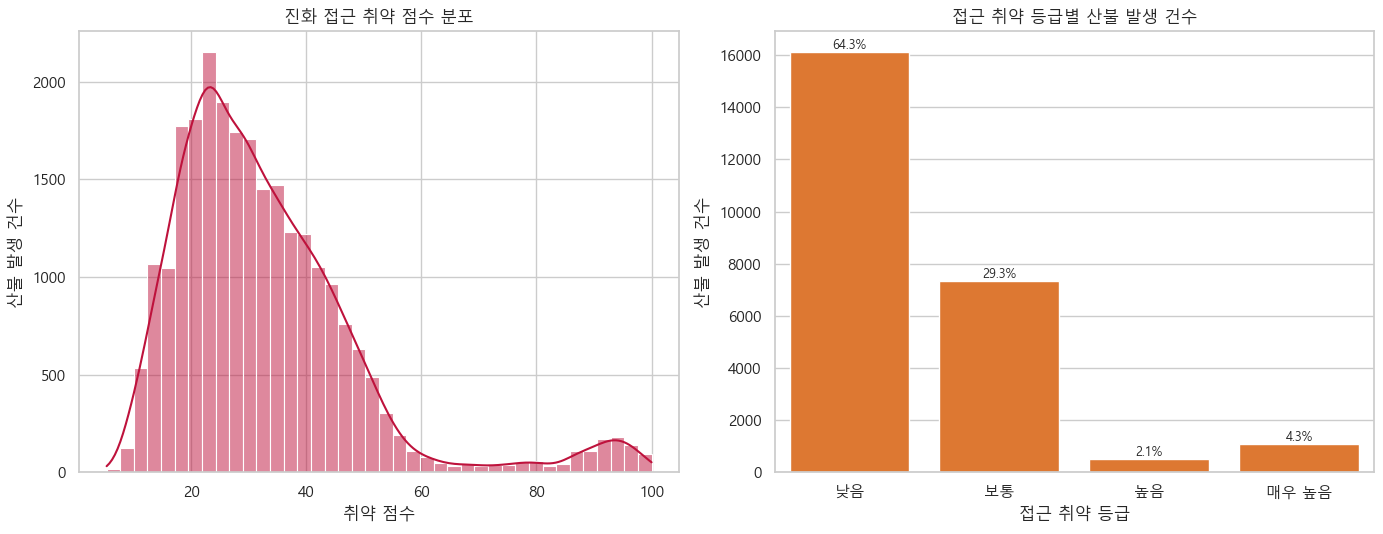

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.histplot(access["진화접근취약점수"], bins=40, kde=True, ax=axes[0], color="#be123c")
axes[0].set_title("진화 접근 취약 점수 분포")
axes[0].set_xlabel("취약 점수")
axes[0].set_ylabel("산불 발생 건수")

sns.barplot(data=grade_summary, x="접근취약등급", y="산불건수", ax=axes[1], color="#f97316")
axes[1].set_title("접근 취약 등급별 산불 발생 건수")
axes[1].set_xlabel("접근 취약 등급")
axes[1].set_ylabel("산불 발생 건수")
for i, row in grade_summary.iterrows():
    axes[1].text(i, row["산불건수"], f"{row['비율_%']:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "integrated_accessibility_score.png", dpi=160)
plt.show()

## 6. 접근 취약 산불 지점 Top 100

In [11]:
top_vulnerable = (
    access.sort_values("진화접근취약점수", ascending=False)
    [[
        "fire_id", "위도", "경도", "진화접근취약점수", "접근취약등급",
        "임도거리_km", "소방서거리_km", "소방용수거리_km", "산불소화시설거리_km",
        "고도(m)", "경사도(도)", "TPI(지형위치지수)", "TWI(지형다습지수)"
    ]]
    .head(100)
)

top_vulnerable.to_csv(OUT_DIR / "top_100_fire_suppression_access_vulnerable.csv", index=False, encoding="utf-8-sig")
access.to_csv(OUT_DIR / "fire_integrated_accessibility_scores.csv", index=False, encoding="utf-8-sig")
distance_summary.to_csv(OUT_DIR / "integrated_distance_summary.csv", encoding="utf-8-sig")
grade_summary.to_csv(OUT_DIR / "integrated_accessibility_grade_summary.csv", index=False, encoding="utf-8-sig")

top_vulnerable.round(2)

,fire_id,위도,경도,진화접근취약점수,접근취약등급,임도거리_km,소방서거리_km,소방용수거리_km,산불소화시설거리_km,고도(m),경사도(도),TPI(지형위치지수),TWI(지형다습지수)
5181,F_005181,38.61,127.17,100.00,매우 높음,51.52,47.04,37.81,35.67,548.37,30.64,-4.75,NaN
5828,F_005828,38.88,127.09,100.00,매우 높음,81.91,77.56,68.80,78.53,563.52,32.43,10.97,NaN
5311,F_005311,38.85,126.91,100.00,매우 높음,80.78,81.98,68.43,69.62,507.53,30.83,0.64,NaN
5122,F_005122,38.18,126.57,100.00,매우 높음,48.24,41.05,28.59,30.31,567.97,30.36,4.90,NaN
5326,F_005326,39.08,126.99,100.00,매우 높음,104.63,101.09,91.68,101.50,644.84,33.78,-8.22,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6356,F_006356,38.63,127.43,97.51,매우 높음,53.80,43.13,36.80,38.84,865.12,22.53,9.94,NaN
6464,F_006464,38.55,127.21,97.50,매우 높음,44.55,39.02,29.79,27.70,646.49,25.94,-1.58,NaN
5933,F_005933,38.69,126.75,97.48,매우 높음,70.22,67.64,59.75,65.04,738.78,22.43,-4.17,NaN
6331,F_006331,38.85,126.84,97.47,매우 높음,82.27,85.16,70.29,72.45,509.21,22.41,-6.07,NaN


## 7. 접근 취약 지역 격자 분석

산불 지점을 0.5도 격자로 묶고 평균 취약 점수와 산불 건수를 함께 봅니다.

In [12]:
grid_size_deg = 0.5
access["lon_grid"] = np.floor(access["경도"] / grid_size_deg) * grid_size_deg
access["lat_grid"] = np.floor(access["위도"] / grid_size_deg) * grid_size_deg

grid_summary = (
    access.groupby(["lat_grid", "lon_grid"])
    .agg(
        산불건수=("fire_id", "count"),
        평균취약점수=("진화접근취약점수", "mean"),
        중앙취약점수=("진화접근취약점수", "median"),
        평균임도거리_km=("임도거리_km", "mean"),
        평균소방서거리_km=("소방서거리_km", "mean"),
        평균소방용수거리_km=("소방용수거리_km", "mean"),
        평균경사도=("경사도(도)", "mean"),
        평균고도_m=("고도(m)", "mean"),
    )
    .reset_index()
)

vulnerable_grid = (
    grid_summary[grid_summary["산불건수"] >= 30]
    .sort_values(["평균취약점수", "산불건수"], ascending=[False, False])
    .head(20)
)

grid_summary.to_csv(OUT_DIR / "integrated_accessibility_grid_summary.csv", index=False, encoding="utf-8-sig")
vulnerable_grid.to_csv(OUT_DIR / "integrated_accessibility_vulnerable_grid_top20.csv", index=False, encoding="utf-8-sig")

vulnerable_grid.round(2)

,lat_grid,lon_grid,산불건수,평균취약점수,중앙취약점수,평균임도거리_km,평균소방서거리_km,평균소방용수거리_km,평균경사도,평균고도_m
74,38.5,127.0,373,93.83,94.00,62.03,54.95,46.07,13.94,570.55
73,38.5,126.5,233,93.49,93.85,68.90,67.79,58.17,15.00,401.53
68,38.0,126.5,284,75.15,82.95,27.18,23.63,16.67,7.77,134.37
50,37.0,126.0,44,53.40,49.27,46.52,10.83,0.80,6.27,28.31
60,37.5,126.0,168,51.75,51.44,45.82,5.42,0.66,5.31,46.60
12,34.5,126.0,156,48.00,49.57,24.04,8.80,0.66,6.00,30.68
8,34.0,127.0,33,47.15,45.92,13.61,19.57,1.63,7.84,49.04
32,35.5,129.0,842,44.22,46.01,24.10,4.85,0.94,8.27,132.60
40,36.0,128.5,490,42.20,43.05,14.76,9.50,1.36,8.92,228.83
31,35.5,128.5,699,42.13,43.60,18.73,4.92,1.08,10.09,188.84


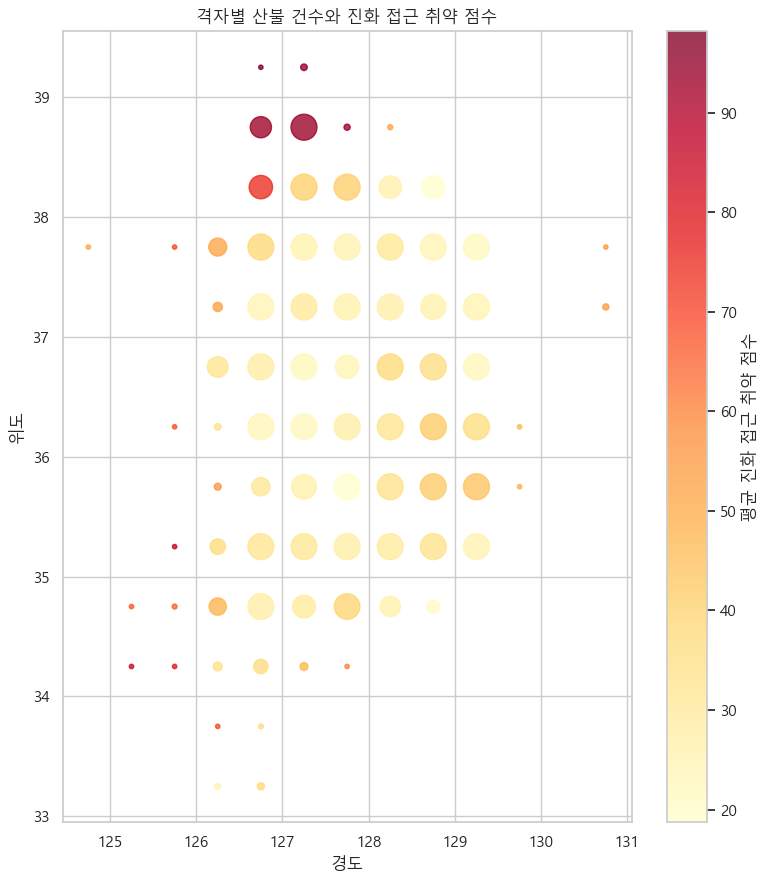

In [13]:
fig, ax = plt.subplots(figsize=(8, 9))
sc = ax.scatter(
    grid_summary["lon_grid"] + grid_size_deg / 2,
    grid_summary["lat_grid"] + grid_size_deg / 2,
    c=grid_summary["평균취약점수"],
    s=np.clip(grid_summary["산불건수"], 10, 350),
    cmap="YlOrRd",
    alpha=0.78,
)
plt.colorbar(sc, ax=ax, label="평균 진화 접근 취약 점수")
ax.set_title("격자별 산불 건수와 진화 접근 취약 점수")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
plt.tight_layout()
plt.savefig(OUT_DIR / "integrated_accessibility_grid_map.png", dpi=180)
plt.show()

## 8. 지도 시각화: 취약 점수

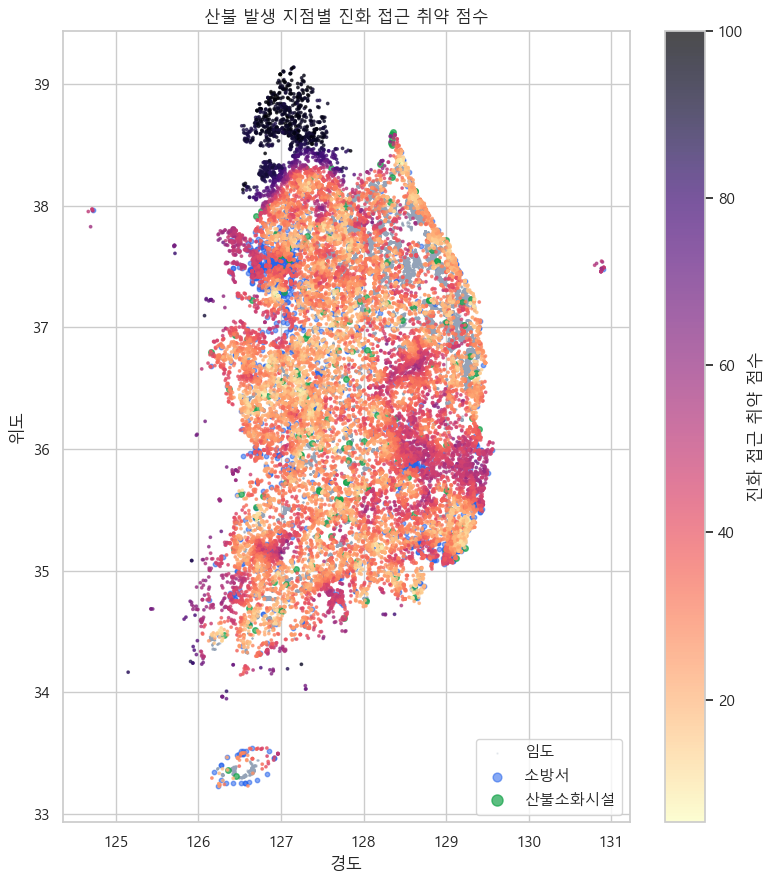

In [14]:
fig, ax = plt.subplots(figsize=(8, 9))
ax.scatter(road_points["경도"], road_points["위도"], s=0.15, c="#94a3b8", alpha=0.16, label="임도")
ax.scatter(stations["경도"], stations["위도"], s=10, c="#2563eb", alpha=0.55, label="소방서")
ax.scatter(forest_ext["경도"], forest_ext["위도"], s=16, c="#16a34a", alpha=0.7, label="산불소화시설")
sc = ax.scatter(
    access["경도"],
    access["위도"],
    c=access["진화접근취약점수"],
    s=3,
    cmap="magma_r",
    alpha=0.7,
)
plt.colorbar(sc, ax=ax, label="진화 접근 취약 점수")
ax.set_title("산불 발생 지점별 진화 접근 취약 점수")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.legend(markerscale=2, loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR / "integrated_accessibility_fire_map.png", dpi=180)
plt.show()

## 9. 인사이트 자동 요약

In [15]:
n = len(access)
high_count = access["접근취약등급"].isin(["높음", "매우 높음"]).sum()
very_high_count = (access["접근취약등급"] == "매우 높음").sum()
road_far = (access["임도거리_km"] >= 10).sum()
station_far = (access["소방서거리_km"] >= 20).sum()
water_far = (access["소방용수거리_km"] >= 5).sum()
hard_terrain = ((access["경사도(도)"] >= 15) & (access["고도(m)"] >= 300)).sum()
complex_vulnerable = (
    (access["임도거리_km"] >= 10)
    & (access["소방서거리_km"] >= 20)
    & (access["소방용수거리_km"] >= 5)
).sum()

print(f"- 분석 대상 산불 지점은 {n:,}건입니다.")
print(f"- 진화 접근 취약 점수 평균은 {access['진화접근취약점수'].mean():.1f}점, 중앙값은 {access['진화접근취약점수'].median():.1f}점입니다.")
print(f"- 접근 취약 등급이 '높음' 이상인 산불 지점은 {high_count:,}건({high_count / n * 100:.1f}%)입니다.")
print(f"- 접근 취약 등급이 '매우 높음'인 산불 지점은 {very_high_count:,}건({very_high_count / n * 100:.1f}%)입니다.")
print(f"- 임도에서 10km 이상 떨어진 산불 지점은 {road_far:,}건({road_far / n * 100:.1f}%)입니다.")
print(f"- 소방서에서 20km 이상 떨어진 산불 지점은 {station_far:,}건({station_far / n * 100:.1f}%)입니다.")
print(f"- 소방용수시설에서 5km 이상 떨어진 산불 지점은 {water_far:,}건({water_far / n * 100:.1f}%)입니다.")
print(f"- 경사도 15도 이상이면서 고도 300m 이상인 지점은 {hard_terrain:,}건({hard_terrain / n * 100:.1f}%)입니다.")
print(f"- 임도/소방서/소방용수가 모두 먼 복합 취약 지점은 {complex_vulnerable:,}건({complex_vulnerable / n * 100:.1f}%)입니다.")

- 분석 대상 산불 지점은 25,036건입니다.
- 진화 접근 취약 점수 평균은 32.8점, 중앙값은 29.5점입니다.
- 접근 취약 등급이 '높음' 이상인 산불 지점은 1,602건(6.4%)입니다.
- 접근 취약 등급이 '매우 높음'인 산불 지점은 1,081건(4.3%)입니다.
- 임도에서 10km 이상 떨어진 산불 지점은 9,509건(38.0%)입니다.
- 소방서에서 20km 이상 떨어진 산불 지점은 1,203건(4.8%)입니다.
- 소방용수시설에서 5km 이상 떨어진 산불 지점은 2,068건(8.3%)입니다.
- 경사도 15도 이상이면서 고도 300m 이상인 지점은 1,860건(7.4%)입니다.
- 임도/소방서/소방용수가 모두 먼 복합 취약 지점은 992건(4.0%)입니다.


### 보고서에 쓸 수 있는 문장

- 산불 진화 접근성은 임도 거리만으로 판단하기 어렵기 때문에, 소방서 거리, 소방용수시설 거리, 산불소화시설 거리, 경사도, 고도를 함께 고려했다.
- 임도와 소방서가 모두 먼 산불 지점은 초기 출동 이후 실제 현장 접근 시간이 길어질 가능성이 있다.
- 소방용수시설과 먼 산불 지점은 진화 장비가 접근하더라도 물 공급 제약이 발생할 수 있다.
- 경사가 급하고 고도가 높은 지역은 장비 접근과 인력 이동이 모두 어려워 진화 난이도가 높을 가능성이 있다.
- 종합 취약 점수가 높은 격자는 임도 확충, 소방용수시설 보강, 산불소화시설 배치 검토의 우선 후보로 활용할 수 있다.